# Recurrent Neural Networks (RNN)

- RNNs are neural networks that can process sequential data with a variable length.
    - Example: the words of a sentence or the price of stock at various moments in time.  

- RNNs apply the **same function (recurrence relation)** at every time steps to process a sequence. 
- RNN as a recurrence relation $s_{t} = f(s_{t-1},x_{t})$
    - $f$ is a differentiable function,
    - $s_{t}$ is a vector of values called the internal network state (at step $t$), 
    - $x_{t}$ is the network input at step $t$. 

<img src="img/rnn.png" width=400 height=400 />

**The RNN has three sets of parameters (or weights):**
- $U$ transforms the input, $x_{t}$, into the state, $s_{t}$.
- $W$ transforms the previous state, $s_{t-1}$, into the current state, $s_{t}$ **(recurrence weight)**
- $V$ maps the newly computed internal state, $s_{t}$, to the output, $y_{t}$.

**Let's define the internal state and the network output as follows**

$s_{t} = f(Ux_{t} + Ws_{t-1})$

$y = Vs_{t}$

where $f$ is the non-linear activation function (such as tanh, sigmoid, or ReLU)


<img src="img/comnactivation.png" width=600 height=600 />

- **RNNs have memory over time** because the states, $s$, contain information based on the previous steps


### RNN Intuition

In [ ]:
my_rnn = RNN()

hidden_state = [0,0,0,0]

sentence = ["I","love","recurrent","neural"]

for word in sentence:
    prediction, hidden_state = my_rnn(word,hidden_state)

next_word_predition = prediction

### RNN in Pytorch

In [ ]:
class MyRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MyRNN, self).__init__()
        self.hidden_size = hidden_size
        self.in2hidden = nn.Linear(input_size + hidden_size, hidden_size)
        self.in2output = nn.Linear(input_size + hidden_size, output_size)
    
    def forward(self, x, hidden_state):
        combined = torch.cat((x, hidden_state), 1)
        hidden = torch.sigmoid(self.in2hidden(combined)) # new memory
        output = self.in2output(combined)
        return output, hidden
    
    ## Might call init_hidden() at the start of every new batch
    def init_hidden(self):
        return nn.init.kaiming_uniform_(torch.empty(1, self.hidden_size))

In [36]:
#torch.nn.RNN(input_size, hidden_size, num_layers=1, 
#             nonlinearity='tanh', bias=True, batch_first=False, 
#             dropout=0.0, #bidirectional=False, device=None, dtype=None)

### Stacked RNN
- We can stack multiple RNNs to form a stacked RNN.

<img src="img/stackrnn.png" width=400 height=400 />

### Bidirectional RNN 

- Useful to extract the context of a word from both the preceding and succeeding words.

<img src="img/bidrnn.png" width=400 height=400 />

### Different RNN combinations

<img src="img/rnnforms.png" width=600 height=600 />

### Backpropagation through time

<img src="img/rnn.png" width=300 height=300 />

- Backpropagation is done at each point in time.

- Very similar to regular multi-layer feedforward network
    - one hidden layer represents one step through time

- The only differences are that **each layer has multiple inputs**:
    - the previous state, $s_{t-1}$,
    - and the current input, $x_{t}$.
    - The parameters $U$ and $W$ are shared between all of the hidden layers.

- Because the weights, $W$ and $U$, are shared across the layers
    - we'll accumulate the error derivatives for each recurrent step,
    - and in the end, we'll update the weights with the accumulated value.

- First, we need to get the gradient of the output, $s_{t}$, with respect to the loss function $(∂J/∂s)$.

<img src="img/jvs.png" width=200 height=200 /> $J$ is the loss function.

- The gradients of the weights, $U$ and $W$, are accumulated as follows.

<img src="img/gradrnn.png" width=150 height=150 />

In [25]:
import numpy as np
# The first dimension represents the mini-batch
x = np.array([[0, 0, 0, 0, 1, 0, 1, 0, 1, 0]])
y = np.array([3])

In [26]:
x.shape

(1, 10)

- Let's first see how the forward is implemented for a simple **linear RNN**

In [27]:
def step(s, x, U, W):
      return x * U + s * W ## input part + memory part
    
def forward(x, U, W):
    
       # Number of samples in the mini-batch
       number_of_samples = len(x)
                              
       # Length of each sample
       sequence_length = len(x[0])
    
       # Initialize the state activation for each sample along the sequence
       s = np.zeros((number_of_samples, sequence_length + 1))
    
       # Update the states over the sequence
       for t in range(0, sequence_length):
           s[:, t + 1] = step(s[:, t], x[:, t], U, W)
           
       return s
 

In [31]:
def backward(x, s, y, W):
    sequence_length = len(x[0])
    
    # The network output is just the last activation of sequence
    s_t = s[:, -1]
    
    # Compute the gradient of the output w.r.t. MSE loss function at final state
    gS = 2 * (s_t - y)

    gU, gW = 0, 0
    # Accumulate gradients backwards
    for k in range(sequence_length, 0, -1):
        # Compute the parameter gradients and accumulate the results
        gU += np.sum(gS * x[:, k - 1])
        gW += np.sum(gS * s[:, k - 1])
        
        # Compute the gradient at the output of the previous layer
        gS = gS * W
        
    return gU, gW

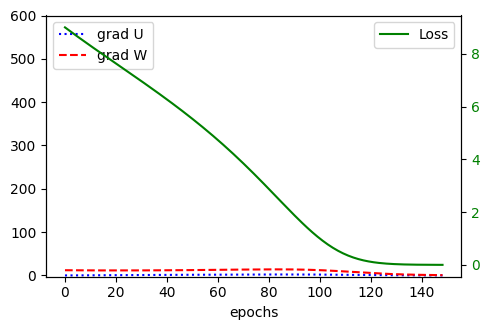

- the gradient grows exponentially if $|W| > 1$ (**Exploding gradient**)
-  or it decays exponentially over the number of steps (**Vanishing gradient**)

## Handling long term dependencies

- **Vanishing/exploding gradient**
    - Both phenomena are often encountered in the context of RNNs.
    - Because it is difficult to capture long term dependencies

- **Gradient clipping**
    - It is a technique used to cope with the exploding gradient problem

## Long short-term memory (LSTM)

- Can handle long-term and short-term dependencies due to a specially crafted memory cell

- It features a dedicated mechanism that determines when to update or reset the hidden state

<center><img src="img/lstm.png" width=400 height=400 /></center>

- The key idea of LSTM is the cell state $c_{t}$
- The cell state can only be modified by specific gates
- These gates are composed of a sigmoid function and element-wise multiplication.
- So the multiplication can only reduce the value running through the gate

**A typical LSTM is composed of three gates:**
- **Forget gate $f_{t}$:** decides whether we want to erase parts of the existing cell state or not

$$\mathbf{F}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xf} + \mathbf{H}_{t-1} \mathbf{W}_{hf} + \mathbf{b}_f)$$

- **input gate $i_{t}$**  decides what new information is going to be added to the memory cell

$$\mathbf{I}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xi} + \mathbf{H}_{t-1} \mathbf{W}_{hi} + \mathbf{b}_i)$$

    - Compute the input node that uses a tanh function

$$\tilde{\mathbf{C}}_t = \tanh(\mathbf{X}_t \mathbf{W}_{xc} + \mathbf{H}_{t-1} \mathbf{W}_{hc} + \mathbf{b}_c)$$

    - The final version of the new cell state

$$\mathbf{C}_t = \mathbf{F}_t \odot \mathbf{C}_{t-1} + \mathbf{I}_t \odot \tilde{\mathbf{C}}_t$$

**Output gate $o_{t}$:** decides what the total cell output is going to be

$$\mathbf{O}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xo} + \mathbf{H}_{t-1} \mathbf{W}_{ho} + \mathbf{b}_o)$$


**Finally,** the LSTM cell output is transferred by a tanh function

$$\mathbf{H}_t = \mathbf{O}_t \odot \tanh(\mathbf{C}_t)$$

## Gated Recurrent Units (GRUs)

- Has fewer parameters than an LSTM and so tends to be quicker to train and uses fewer resources at runtime.


<center><img src="img/gunit.png" width=400 height=400 /></center>

- the LSTM’s three gates are replaced by two: **the reset gate and the update gate.**


**Reset Gate:** Decides how much of the past information to forget.
    
    - help capture short-term dependencies in sequences.

$$\mathbf{R}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xr} + \mathbf{H}_{t-1} \mathbf{W}_{hr} + \mathbf{b}_r)$$


**Update Gate:** Determines how much of the past information needs to be passed along to the future.
    
    - help capture long-term dependencies in sequences



$$\mathbf{Z}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xz} + \mathbf{H}_{t-1} \mathbf{W}_{hz} + \mathbf{b}_z)$$



**Candidate Hidden State**

$$\tilde{\mathbf{H}}_t = \tanh(\mathbf{X}_t \mathbf{W}_{xh} + (\mathbf{R}_t \odot \mathbf{H}_{t-1}) \mathbf{W}_{hh} + \mathbf{b}_h)$$


**Finally,** we incorporate the effect of the update gate 

- Old state $H_{t-1}$: what the network already remembers.
    
- Candidate state $\tilde{H_t}$: the new content computed from the current input.
    
- $Z_t$ sets the mixing ratio between them. It is a vector of values between $0$ and $1$, one per hidden unit.

$$\mathbf{H}_t = \mathbf{Z}_t \odot \mathbf{H}_{t-1} + (1 - \mathbf{Z}_t) \odot \tilde{\mathbf{H}}_t$$